# Pareto fronts under Type I, II and III codes

`PF00595 x PF00013`, the smallest pair of Task 1 (71 + 58 aa), at overlap 166 nt --
frame 1, one below this pair's maximum of 168, and the frame the standard code
fails in.

Sampling is `20260821_all_codes_all_pairs.py`'s -- the cluster scan that produced
`20260821_all_rows.csv` -- unchanged and **including the codon-degeneracy
correction**: 121 replicas over `T` in [0.3, 1.0], `N_swap` 1000, `N_equil` 1e5,
`N_thin` `N_total`/1000, `discard_frac` 0.2, `ln_n = codon_degeneracy_ln_n()`.
The correction enters the local MC acceptance only, so the `E1`/`E2` plotted
below are the original DCA energies and the `z` here is directly comparable with
that csv's rows.

Each code runs in its own process via `20260820_pareto_run.py`, because
`set_genetic_code` is baked into the numba kernel at first compilation and a
single kernel cannot hold four codes.  `ln_n` has the same hazard -- Type II and
Type III change the per-amino-acid codon counts -- so it is computed inside that
process, after the code is installed.


In [1]:
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk", rc = {"font.size":15, "axes.titlesize":15, "axes.labelsize":15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--',
                            'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

colorTable = {}
colorTable['k'] = [0, 0, 0]
colorTable['g'] = [27/255, 158/255, 119/255]
colorTable['o'] = [217/255, 95/255, 2/255]
colorTable['p'] = [117/255, 112/255, 179/255]

codelabel = {"standard": "standard", "shuffled": "Type I",
             "permuted": "Type II", "scrambled": "Type III"}
codecolor = {"standard": colorTable['k'], "shuffled": colorTable['o'],
             "permuted": colorTable['p'], "scrambled": colorTable['g']}


In [2]:
# One representative code per type: the seed whose z is closest to that type's
# median over the 15 cluster seeds at this pair and overlap in
# 20260821_all_rows.csv, so these are typical rather than picked.  (Recomputed
# against that csv: the earlier seeds 7/24/19 came from the 30-seed uncorrected
# run, and 24 and 19 do not exist in this one.)
EXAMPLES = [("standard", -1), ("shuffled", 10), ("permuted", 6), ("scrambled", 4)]

N_TOTAL   = int(1e7)   # the cluster's value; 1e6 also retains 800 samples/replica
N_WORKERS = 5          # 4 codes x 5 workers fills this 20-core machine
OUTDIR    = "Pareto Runs"


def cached(path):
    """A usable cache is one that exists AND was written with the correction."""
    if not os.path.exists(path):
        return False
    with np.load(path, allow_pickle = True) as z:
        return int(z["degeneracy_corrected"]) == 1 if "degeneracy_corrected" in z else False


# One process per code, all four at once.  Cached: delete the npz to recompute.
jobs = []
for code_type, seed in EXAMPLES:
    out = f"{OUTDIR}/N{N_TOTAL:.0e}_{code_type}.npz".replace("e+0", "e")
    if not cached(out):
        jobs.append(subprocess.Popen(
            [sys.executable, "-u", "20260820_pareto_run.py", code_type, str(seed),
             str(N_TOTAL), out, str(N_WORKERS)],
            env = {**os.environ, "OMP_NUM_THREADS": "1", "MKL_NUM_THREADS": "1",
                   "OPENBLAS_NUM_THREADS": "1", "NUMBA_NUM_THREADS": "1"}))
for j in jobs:
    assert j.wait() == 0, "a run failed"

runs = {}
for code_type, seed in EXAMPLES:
    out = f"{OUTDIR}/N{N_TOTAL:.0e}_{code_type}.npz".replace("e+0", "e")
    runs[code_type] = dict(np.load(out, allow_pickle = True))
    r = runs[code_type]
    assert int(r["degeneracy_corrected"]) == 1
    print(f"{codelabel[code_type]:9s} seed {int(r['code_seed']):3d}   "
          f"z = {float(r['zscore_dist']):+.3f}   {len(r['E1'])} samples   "
          f"{float(r['seconds']) / 60:.2f} min")


shuffled:10  PF00595(71) x PF00013(58)  overlap 166 nt (frame 1)  N_total 1e+07  n_workers 5  degeneracy-corrected
scrambled:4  PF00595(71) x PF00013(58)  overlap 166 nt (frame 1)  N_total 1e+07  n_workers 5  degeneracy-corrected
permuted:6  PF00595(71) x PF00013(58)  overlap 166 nt (frame 1)  N_total 1e+07  n_workers 5  degeneracy-corrected
standard:-1  PF00595(71) x PF00013(58)  overlap 166 nt (frame 1)  N_total 1e+07  n_workers 5  degeneracy-corrected


  within=False  z=+1.430   96800 samples   6.55 min


  within=False  z=+1.595   96800 samples   6.66 min


  within=True   z=-1.030   96800 samples   6.80 min


  within=False  z=+0.052   96800 samples   6.84 min
standard  seed  -1   z = +1.430   96800 samples   6.55 min
Type I    seed  10   z = -1.030   96800 samples   6.80 min
Type II   seed   6   z = +1.595   96800 samples   6.66 min
Type III  seed   4   z = +0.052   96800 samples   6.84 min


In [3]:
def plot_pareto(ax, run, pltlim):
    """Samples + Pareto front + dominated region + natural mean cross-hair."""
    E1, E2 = run["E1"], run["E2"]
    pf = run["pareto_front"]                       # sorted by E1 ascending
    mu1, sig1 = float(run["mu1"]), float(run["sig1"])
    mu2, sig2 = float(run["mu2"]), float(run["sig2"])
    thistype = str(run["code_type"])

    ax.scatter(E1, E2, s = 1, alpha = 0.1, color = "gray", rasterized = True)

    # Dominated region: the front, closed off through the upper-right corner.
    poly_x = np.concatenate([[pf[0, 0]], pf[:, 0], [pltlim[1], pltlim[1], pf[0, 0]]])
    poly_y = np.concatenate([[pltlim[3]], pf[:, 1], [pf[-1, 1], pltlim[3], pltlim[3]]])
    ax.fill(poly_x, poly_y, color = codecolor[thistype], alpha = 0.15, zorder = 0)
    ax.plot(pf[:, 0], pf[:, 1], "-", color = codecolor[thistype], lw = 1.2, zorder = 4, rasterized = True)

    # Natural mean, with 1 s.d. arms.
    ax.plot([mu1 - sig1, mu1 + sig1], [mu2, mu2], "-", color = "k", zorder = 5)
    ax.plot([mu1, mu1], [mu2 - sig2, mu2 + sig2], "-", color = "k", zorder = 5)
    ax.plot(mu1, mu2, "o", color = "k", ms = 10, mew = 2, zorder = 6)
    ax.axvline(mu1, color = "k", ls = "--", zorder = 1)
    ax.axhline(mu2, color = "k", ls = "--", zorder = 1)

    ax.set_xlim(pltlim[0], pltlim[1])
    ax.set_ylim(pltlim[2], pltlim[3])
    ax.set_title(f"{codelabel[thistype]}   $z$ = {float(run['zscore_dist']):+.2f}", color = codecolor[thistype])
    ax.grid(False)


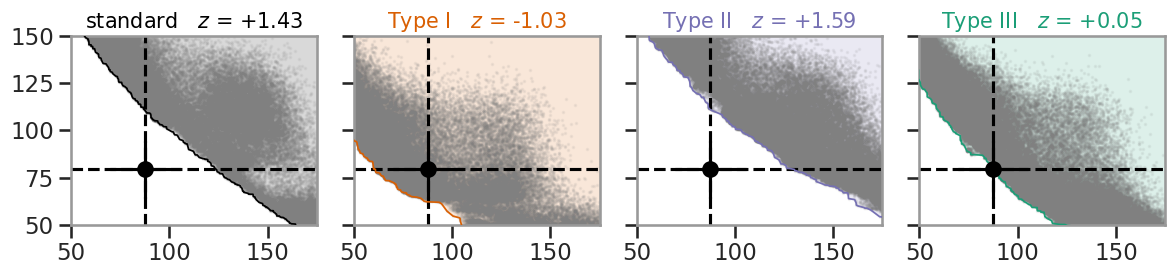

In [4]:
# Shared limits, so the four panels are directly comparable.
pad = 0.05
allE1 = np.concatenate([r["E1"] for r in runs.values()] + [[float(r["mu1"])] for r in runs.values()])
allE2 = np.concatenate([r["E2"] for r in runs.values()] + [[float(r["mu2"])] for r in runs.values()])
pltlim = (allE1.min() - pad * np.ptp(allE1), allE1.max() + pad * np.ptp(allE1),
          allE2.min() - pad * np.ptp(allE2), allE2.max() + pad * np.ptp(allE2))

fig, axes = plt.subplots(1, len(EXAMPLES), figsize = (3 * len(EXAMPLES), 3),
                         sharex = True, sharey = True)
for ax, (code_type, _) in zip(axes, EXAMPLES):
    plot_pareto(ax, runs[code_type], pltlim)

r0 = runs[EXAMPLES[0][0]]
# axes[0].set_ylabel(f"$E_2$  ({str(r0['pf2'])})")
# fig.text(0.5, -0.02, f"$E_1$  ({str(r0['pf1'])})", ha = "center")
# fig.suptitle(f"{str(r0['pf1'])} x {str(r0['pf2'])},  overlap {int(r0['overlap_nuc'])} nt "
#              f"(frame {int(r0['frame'])}),  $N$ = {int(r0['n_total']):.0e}",
#              fontsize = 15, y = 1.04)
axes[0].set_xlim(50, 175)
axes[0].set_ylim(50, 150)

plt.tight_layout()
os.makedirs("Panels", exist_ok = True)
plt.savefig("Panels/Pareto_Examples.svg", bbox_inches = "tight", dpi = 300)